# Percentiles, Credible Intervals, and Error Bars

Suppose that we have a continuous random variable $x$ defined on the real line $x \in (-\infty, \infty)$ which is described by a probability density $P(x)$. In statistics, not only do we want to be able to calculate things like the mean, median and standard deviation of a distribution, but we often want to make statements such as "there is a 68% probability that $x$ lies between $x_1$ and $x_2$. The interval $x_1 \leq x \leq x_2$ is called a **credible interval** or a **confidence interval** (depending on the context).  Let $Q$ be the probability that we have chosen to define our credibile interval (i.e. the 68%). To compute the credibile interval mathematically, we write
$$
Q = P(x_1 \leq x \leq x_2) = \int_{x_1}^{x_2} P(x) dx. 
$$
But recall that the cumulative distribution function (CDF) is defined as
$$
{\rm CDF}(\leq x) = \int_{-\infty}^x P(x') dx'.
$$
Note that 
$$
\begin{align}
{\rm CDF}(\leq x_2) - {\rm CDF}(\leq x_1) =& \int_{-\infty}^{x_2} P(x') dx' - \int_{-\infty}^{x_1} P(x') dx'\nonumber\\
=& \int_{-\infty}^{x_1} P(x') dx' + \int_{x_1}^{x_2} P(x') dx' - \int_{-\infty}^{x_1} P(x') dx'\nonumber\\
=& \int_{x_1}^{x_2} P(x') dx' = P(x_1 \leq x \leq x_2) = Q.\nonumber
\end{align}
$$
and hence
$$
Q = P(x_1 \leq x \leq x_2) = {\rm CDF}(\leq x_2) - {\rm CDF}(\leq x_1).
$$
But note that the equation above is not enough to uniquely define $x_1$ and $x_2$, because it can be satified by many different combinations of $x_1$ and $x_2$ (i.e. we have one constraint $Q$ and two unknowns $x_1$ and $x_2$).

While there are multiple ways/conventions to break this degeneracy and define the credible interval, a common practice is to choose $x_1$ and $x_2$ such that the probability that $x$ lies below $x_1$ is the same as the probability that $x$ lies above $x_2$. In other words, 
$$
\begin{align}
\frac{1}{2}(1-Q) =& P(x \leq x_1) = \int_{-\infty}^{x_1} P(x) dx = {\rm CDF}(\leq x_1)\nonumber\\
& \quad\quad\quad\quad\quad\quad \text{and}\nonumber\\
\frac{1}{2}(1-Q) =& P(x \geq x_2) = \int_{x_2}^{\infty} P(x) dx = 1 - {\rm CDF}(\leq x_2)\nonumber.
\end{align}
$$
You can easily show that taking the sum of these equations gives $Q = {\rm CDF}(\leq x_2) - {\rm CDF}(\leq x_1)$, as required. 
The equations above can be solved for $x_1$ and $x_2$ by inverting the CDF 
$$
\begin{align}
x_1 =& {\rm CDF}^{-1}\left(\frac{1}{2}(1-Q)\right)\nonumber\\
x_2 =& {\rm CDF}^{-1}\left(\frac{1}{2}(1+Q)\right)\nonumber
\end{align}
$$

Note that similar to our discussion of the mean, median, and standard deviation, there are two ways to compute the credible interval bounds. The first way is to operate directly on samples from the distribution, the second way is to use the CDF. We will illustrate both methods below for the case of the Gaussian distribution.

## Example: Compute the 68% Credible Interval for the Gaussian Distribution

Recall the Gaussian distribution is defined by the probability density
$$
\mathcal{N}(x| \mu, \sigma) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right],
$$
where $\mu$ is the mean of $x$ and $\sigma$ is the standard deviation.

First we can use `np.percentile` to compute the credible interval directly from samples from the distribution.

In [1]:
import numpy as np
from scipy import stats

seed=42
rng = np.random.default_rng(seed)

x = rng.normal(loc=0.0, scale=1.0, size=(1000000,))

Q=0.68
Q_1 = (1-Q)/2 # 0.16
Q_2 = (1+Q)/2 # 0.84
x_1 = np.percentile(x, Q_1*100.0)
x_2 = np.percentile(x, Q_2*100.0)

# Print out the credible interval for the 68% confidence level
print(f'The 68% credible interval: {x_1:.4f} <= x <= {x_2:.4f}]')

The 68% credible interval: -0.9937 <= x <= 0.9943]


Second,  we can use the CDF this is easiest to do with `scipy.stats`. 

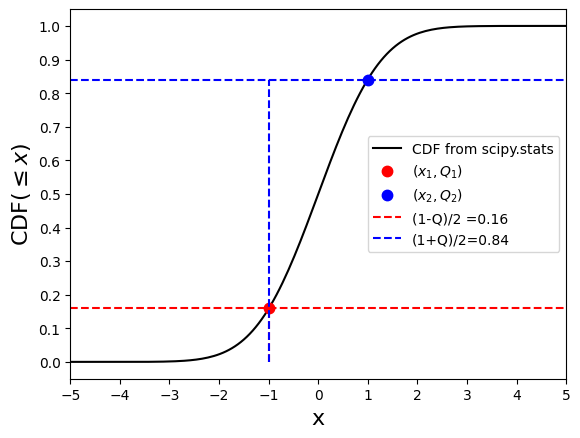

In [2]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
mu =0
sigma = 1.0
# Compute the cumulative distribution function from scipy.stats
x_fine = np.linspace(-20, 40, 1000)
cdf_scipy = stats.norm.cdf(x_fine, loc=mu, scale=sigma)

# Scipy actual has a function that inverts the cdf for us called the precent point function (ppf)
x_1_ppf = stats.norm.ppf(Q_1, loc=mu, scale=sigma)
x_2_ppf = stats.norm.ppf(Q_2, loc=mu, scale=sigma)

# Plot the cumulative distribution function from scipy.stats
plt.plot(x_fine, cdf_scipy, 'k-', label='CDF from scipy.stats')

# Add labels and legend
plt.xlabel('x', fontsize=16)
plt.ylabel(r'${\rm CDF}(\leq x)$', fontsize=16)
plt.legend()
plt.xlim(-5, 5)
plt.plot([x_1], [Q_1], 'r.', markersize=15, label=r'$(x_1, Q_1)$')
plt.plot([x_2], [Q_2], 'b.', markersize=15, label=r'$(x_2, Q_2)$')
plt.axhline(Q_1, color='r', linestyle='--', label='(1-Q)/2 =0.16')
plt.axhline(Q_2, color='b', linestyle='--', label='(1+Q)/2=0.84')
plt.plot([x_1_ppf,x_1_ppf], [0, Q_1], color='r', linestyle='--')
plt.plot([x_1_ppf,x_1_ppf], [0, Q_2], color='b', linestyle='--')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))
plt.legend()
plt.show()



It is not a coincidence that we found that $x_1 = -1$ and $x_2=1$ for the Gaussian distribution with $\mu=0$ and $\sigma=1$. Indeed, the probability level $Q=0.68$, 
or the 68% credibility level is often quoted because it is the probability that a random variable drawn from a Gaussian distribution (with $\mu=0$ and $\sigma=1$) lies within one standard deviation of the mean.  Because the Gaussian distribution is so common, it sets the *standard* for the credibility levels ($Q$) that are commonly quoted, and the **error bars** that we quote and plot on measurements. 

As illustrated in the figure below: 
- The mean $\mu$ of the distribuiton is also equal to the median. 
- 68% of the values lie within one standard deviation $\sigma$ of the mean $\mu$.
- 95% of the values lie within two standard deviations $2\sigma$ of $\mu$.
- 99.7% are within three standard deviations $3\sigma$ of $\mu$.

<img src="figures/gaussian_wikipedia.png" width="800">

We can verify these numbers with `scipy.stats`. 

In [3]:
from scipy.stats import norm

mu = 0.0
sigma = 1.0

# Create a normal distribution object
dist = norm(loc=mu, scale=sigma)
# Compute the cumulative distribution function of the Gaussian at  mu - sigma and mu + sigma
lower_percentile_16 = 100*dist.cdf(mu - sigma) # 15.9% of the probability below mu - sigma
upper_percentile_84 = 100*dist.cdf(mu + sigma) # 84.1% of the probability below mu + sigma

print(f'The percentile for mu - sigma is: {lower_percentile_16}')
print(f'The percentile for mu + sigma is: {upper_percentile_84}')
print(f'Bewteen mu - sigma and mu + sigma is: {upper_percentile_84 - lower_percentile_16}')

The percentile for mu - sigma is: 15.865525393145708
The percentile for mu + sigma is: 84.1344746068543
Bewteen mu - sigma and mu + sigma is: 68.2689492137086


Even if a distribution is not Gaussian, it is common to use a standard set of confidence levels to describe the spread of the distribution.  For example, consider our US income distribution, which is not Gaussian.  We can nevertheless compute its 16th, 50th, and 84th percentile incomes, to get a feeling for how the distribution behaves. For a Gaussian distribution, the 16th, 50th, and 84th percentiles correspond to the mean/median (they are the same for a Gaussian) minus/plus the standard deviation. This will not be the case for a non-Gaussian distribution like the US income distribution, but we can still compute these percentiles and use them to describe the distribution.

As we saw with computing the median above, we can either compute percentiles directly from a set of random samples (a dataset), or we can compute them via the cumulative distribution function (CDF), i.e. either by integrating a probability distribution or summing a histogram.  Here are examples of both: 

In [6]:
# Generate our fake US census income data
from Phys29.lectures.Week7.census_utils import generate_fake_census_data
incomes = generate_fake_census_data()

# Compute percentiles directly from the data. Use the np.percentile function
income_16 = np.percentile(incomes, lower_percentile_16)
income_50 = np.percentile(incomes, 50.0) # This is equivalent to taking the median
income_84 = np.percentile(incomes, upper_percentile_84)
print(f'16th-50th-84th percentiles from samples: ${income_16:.2f}, ${income_50:.2f}, ${income_84:.2f}')

16th-50th-84th percentiles from samples: $25048.68, $73000.00, $165900.00


In [7]:
# Another way would be to use the cumulative distribution as with the median

# Construct the bins of the histogram 
bin_width = 10000
# Maximum value is 2,481,200, so go up to 2.5 million
I_edges = np.arange(0, 2500000, bin_width)

# Compute the histogram. Use the weights argument given how the census data is provided. 
N_of_I, _ = np.histogram(incomes, bins=I_edges)
I_centers = (I_edges[1:] + I_edges[:-1])/2
P_of_I = N_of_I / np.sum(N_of_I) # Normalize the histogram to get the probability density function

P_cumulative = np.cumsum(P_of_I) 
# Cumsum means P_cumulative[0] = P_of_I[0], P_cumulative[1] = P_of_I[0] + P_of_I[1], etc.
k_16 = np.argmax(P_cumulative > lower_percentile_16/100)
k_med = np.argmax(P_cumulative > 0.5) 
k_84 = np.argmax(P_cumulative > upper_percentile_84/100)
I_16 = I_centers[k_16]
I_median = I_centers[k_med]
I_84 = I_centers[k_84]
print(f'16th-50th-84th percentiles from CDF: ${I_16:.2f}, ${I_median:.2f}, ${I_84:.2f}')

16th-50th-84th percentiles from CDF: $25000.00, $75000.00, $165000.00


Finally, these common percentiles provide a standard way for summarizing physical measurements. In Week5 we discussed the idea of making a plot with error bars. 
For example if we make measurements of a quantity ${\hat x}_0$ that is noisy, and the noise follows a Gaussian distribution (a common occurence), that is
$$
P(x_0) = \mathcal{N}(x_0|{\hat x}_0, \sigma_{x_0}), 
$$
where we take $\mu={\hat x}_0$ to be the mean and $\sigma_{x_0}$ is the standard deviation that comes from say our measurement apparatus. 

In this case, a concise summary of our measurement is to write
$$
x_0 = {\hat x}_0 \pm \sigma_{x_0}. 
$$
The $\pm$ is a convention that indicates  the lower 16th and upper 84th percentiles of the variable. Since our distribution is Gaussian, this is equivalent to $\pm$ the standard deviation, 
and futhermore, the 16th and 84th percentiles are symmetric about the mean/median.  The plus and minus values defined in this way are also the **error bars** that you would use if you were plotting such noisy data (see Week5 lecture). Note that in general the 16th and 84th percentiles denoted by the $\pm$ will not always be symmetric about the mean. 

For example, if we imagine the household incomes of the United States as a noisy measurement drawn from the skewed income distribution that we plotted above, based on what we found above for the percentiles, we would write: 
$$
{\rm income} = \$73,000_{-47951}^{+92900}. 
$$
Because the 16th-50th-84th percentiles,  \$25,049, \$73,000, \$165,900$, are not symmetric about the median, we thus quote the assymetric error bars in this way. 